In [101]:
## checking the dataset properties

import pandas as pd

df= pd.read_csv("../Dataset/sample_tickets_dataset.csv")
print(df.shape)
print(df.columns.tolist)
print(df.dtypes)

(4500, 17)
<bound method IndexOpsMixin.tolist of Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')>
Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
Firs

In [102]:
for columns in df.columns:
    print(df[columns].value_counts())

Ticket ID
1       1
2       1
3       1
4       1
5       1
       ..
4496    1
4497    1
4498    1
4499    1
4500    1
Name: count, Length: 4500, dtype: int64
Customer Name
Scott James          5
Adam Moore           4
Jerry Scott          4
Samantha Lopez       4
Richard Moore        4
                    ..
Margaret Robinson    1
David Jones          1
Tyler Smith          1
Kevin Miller         1
Henry White          1
Name: count, Length: 3690, dtype: int64
Customer Email
mmoore@live.com           2
jchavez@hotmail.com       2
green25@yahoo.com         2
ortiz50@icloud.com        2
lcruz@comcast.net         2
                         ..
miller88@outlook.com      1
donaldyoung@live.com      1
scox@comcast.net          1
henrywhite@gmail.com      1
paul_bennett@yahoo.com    1
Name: count, Length: 4463, dtype: int64
Customer Age
50    102
33     96
19     95
60     95
22     94
44     91
36     91
61     90
64     90
52     90
24     90
69     89
47     88
59     87
42     87
62     

## what we have learnt from the initial raw dataset

1. ticket type will be the main classification target, based on what type of theticket is talking about, we will predict the priority of the ticket

2. the ticket description has one main issue of having {product purchased} and {error_message} which are unfilled parameters which makes this column very weak by itelse. So we combine it with ticket subject to me used more reliablely

3. we can remove unneccessary columns like ticket id, customer name, customer emal, age, gender etc

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Ryan Allen,allen37@icloud.com,61,Female,CoreManage,29-07-2022,Refund Request,Service outage credit or refund request,The device stopped working completely after ex...,Resolved,Refund processed within 5-7 business days to o...,Low,Social Media,50.84 hours,9.3 days,4.0
1,2,Susan Morris,smorris@icloud.com,58,Female,SecureVault,19-06-2023,Technical Issue,Export feature broken since yesterday,My notes and files aren't syncing between my p...,Closed,Configuration error found and corrected. Funct...,High,Social Media,6.36 hours,2.7 days,5.0
2,3,Aaron Kim,akim@outlook.com,64,Male,ConnectHub,29-08-2023,Technical Issue,Software not loading after latest update,I synced my Google Calendar with your app last...,Closed,Configuration error found and corrected. Funct...,High,Chat,6.71 hours,1.1 days,4.0
3,4,Debra Morgan,morgan91@protonmail.com,50,Female,StreamLine CRM,08-09-2025,Technical Issue,Data not syncing between devices anymore,Two-step verification is set up on my account ...,Open,NaN,Critical,Email,0.7 hours,NaN,NaN
4,5,Julie Bailey,jbailey@yahoo.com,32,Female,OmniTrack,21-09-2023,Refund Request,Never received my order need refund now,My order was placed three weeks ago and it sti...,Pending,NaN,Medium,Phone,13.28 hours,NaN,NaN


In [105]:
print(df.shape)

(4500, 17)


In [106]:
## checking null values
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      1732
Ticket Priority                    0
Ticket Channel                     0
First Response Time                0
Time to Resolution              1732
Customer Satisfaction Rating    1732
dtype: int64

In [107]:
## dropping unneccessary columns
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [108]:
df = df.drop(columns=['Ticket ID','Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender',
               'Date of Purchase','First Response Time','Time to Resolution','Resolution', 
               "Customer Satisfaction Rating"],errors='ignore')

In [109]:
df.head()

,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel
0,CoreManage,Refund Request,Service outage credit or refund request,The device stopped working completely after ex...,Resolved,Low,Social Media
1,SecureVault,Technical Issue,Export feature broken since yesterday,My notes and files aren't syncing between my p...,Closed,High,Social Media
2,ConnectHub,Technical Issue,Software not loading after latest update,I synced my Google Calendar with your app last...,Closed,High,Chat
3,StreamLine CRM,Technical Issue,Data not syncing between devices anymore,Two-step verification is set up on my account ...,Open,Critical,Email
4,OmniTrack,Refund Request,Never received my order need refund now,My order was placed three weeks ago and it sti...,Pending,Medium,Phone


In [110]:
## checking null values again
df.isnull().sum()

Product Purchased     0
Ticket Type           0
Ticket Subject        0
Ticket Description    0
Ticket Status         0
Ticket Priority       0
Ticket Channel        0
dtype: int64

for ticket types count: 

Ticket Type
Technical Issue    1530
Billing Inquiry     990
Account Access      855
Refund Request      675
Product Inquiry     450
Name: count, dtype: int64

for ticket priority count: 

Ticket Priority
High        1739
Medium      1378
Critical     935
Low          448
Name: count, dtype: int64


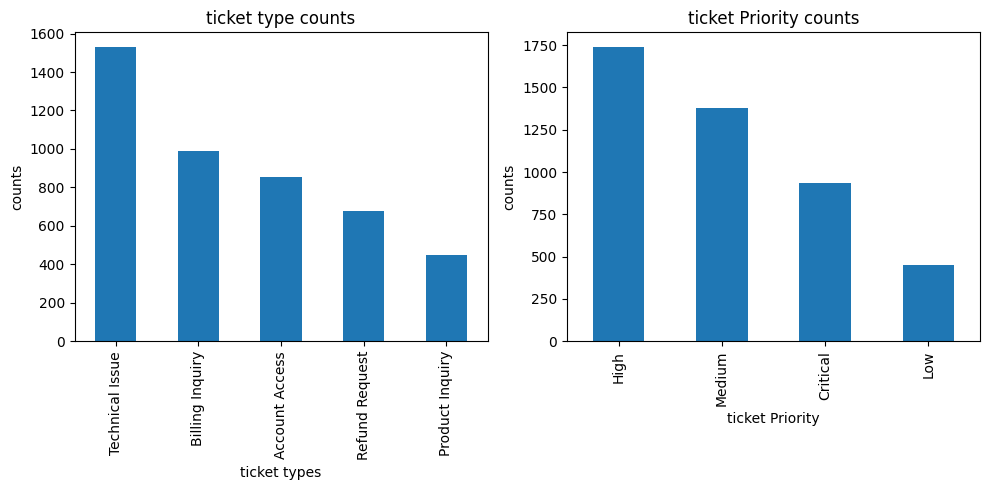

In [111]:
print("for ticket types count: \n")
print(df['Ticket Type'].value_counts())

print("\nfor ticket priority count: \n")
print(df['Ticket Priority'].value_counts())
ticket_type_counts = df['Ticket Type'].value_counts()
ticket_priority_counts = df['Ticket Priority'].value_counts()

figure, axes = plt.subplots(1,2, figsize=(10,5))

ticket_type_counts.plot(kind='bar',ax=axes[0])
axes[0].set_xlabel("ticket types")
axes[0].set_title("ticket type counts")
axes[0].set_ylabel("counts")

ticket_priority_counts.plot(kind='bar',ax=axes[1])
axes[1].set_xlabel("ticket Priority")
axes[1].set_title("ticket Priority counts")
axes[1].set_ylabel("counts")



plt.tight_layout()
plt.show()

### insight from the graphs
- technical issue has the highest ticket count while product enquirey has the least
- high ticket priotiry is the most common where as low ticket priority is the least

In [112]:
## checking the correlation between priority and type using heatmap
print(pd.crosstab(df['Ticket Type'], df['Ticket Priority']))
# this crosstab shows that for each type of ticket how many tickets are criticla, high, low and medium

Ticket Priority  Critical  High  Low  Medium
Ticket Type                                 
Account Access        233   365   49     208
Billing Inquiry       151   394  104     341
Product Inquiry        21    80  127     222
Refund Request         70   204   99     302
Technical Issue       460   696   69     305


<Axes: xlabel='Ticket Priority', ylabel='Ticket Type'>

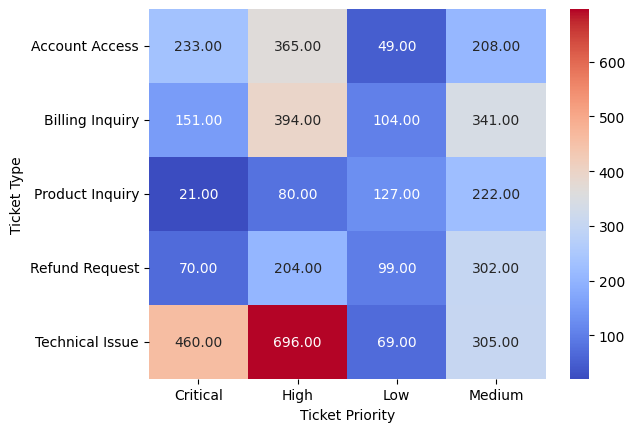

In [113]:
sns.heatmap(pd.crosstab(df['Ticket Type'], df['Ticket Priority']), annot=True,fmt=".2f", cmap="coolwarm")

### insight from heatmap
- Technical Issues are predominantly High priority (696). 
- Product Inquiry leans Medium/Low

this makes ticket priority as a useful feature in classificatin

Ticket Channel
Email           1575
Chat            1235
Phone           1181
Social Media     509
Name: count, dtype: int64


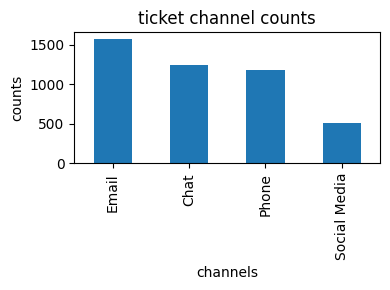

In [114]:
## observing ticket channel distribution
# here we will check choch channel gets most tickets

print(df["Ticket Channel"].value_counts())
ticket_channel_counts = df["Ticket Channel"].value_counts()

plt.figure(figsize=(4,3))

ticket_channel_counts.plot(kind="bar")
plt.title("ticket channel counts")
plt.xlabel("channels")
plt.ylabel("counts")
plt.tight_layout()

plt.show()

### insight from the channel counts
- emails are the major source of connecting
- social media is the least used

In [115]:
## obsering text length distribution
df['description_length'] = df['Ticket Description'].str.len()
df.head()

,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel,description_length
0,CoreManage,Refund Request,Service outage credit or refund request,The device stopped working completely after ex...,Resolved,Low,Social Media,208
1,SecureVault,Technical Issue,Export feature broken since yesterday,My notes and files aren't syncing between my p...,Closed,High,Social Media,182
2,ConnectHub,Technical Issue,Software not loading after latest update,I synced my Google Calendar with your app last...,Closed,High,Chat,196
3,StreamLine CRM,Technical Issue,Data not syncing between devices anymore,Two-step verification is set up on my account ...,Open,Critical,Email,199
4,OmniTrack,Refund Request,Never received my order need refund now,My order was placed three weeks ago and it sti...,Pending,Medium,Phone,203


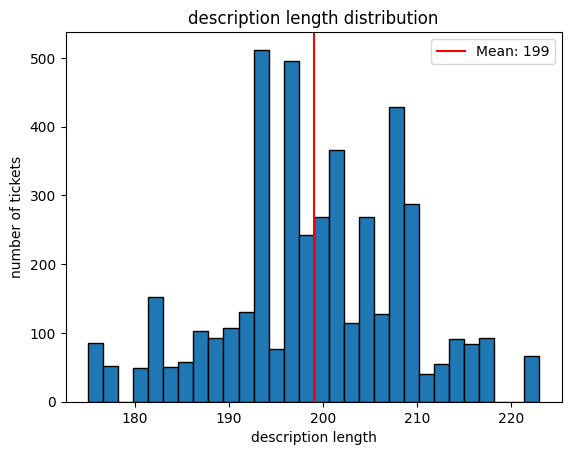

In [116]:
# plotting the histogram
plt.hist(df['description_length'], bins=30, edgecolor='black')
plt.xlabel('description length')
plt.ylabel('number of tickets')
plt.title("description length distribution")
plt.axvline(df['description_length'].mean(), color='red', label=f"Mean: {df['description_length'].mean():.0f}")
##axvline = draws a vertical line at mean
plt.legend()
plt.show()

### insights from description length distribution
- most of the tickets have characters from about 190 to 210 with the maximumn tickets being at 195 characters length
- there might be some description that might be too brief for the model to classify well